# Project 
This notebook runs the entire pipeline from loading models to generateting training loss plots and accuracy on held out data.
Be aware, running the entire notebook takes more than 30 hours and can lead to memory errors. Recommended minimum of 24 GB RAM.
To run API calls to the Deepseek model, an API key at openrouter must be set.

Note: This is not a finished product in any way, and can include several bugs. The full pipeline have never been run from start to finish in one go, and might contain bugs. 

In [1]:
# imports
import os
import torch
from transformers import pipeline
from huggingface_hub import snapshot_download
import requests
import random
import re
from sympy import *
from sympy.utilities.lambdify import lambdify
import json
from datetime import datetime
import numpy as np
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
from transformers import pipeline


In [ ]:
# Set OPENROUTER_API_KEY outside the notebook before enabling API generation.
# This is not neccessary for reproduction, as training data is attached in the repository.

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    print("OPENROUTER_API_KEY is not set; local-only cells remain usable.")

In [ ]:
# Running this cell will download the LLaMA-3.2-3B model from Hugging Face and cache it locally for future use, this takes several GB of storage.
# Set local model cache directory
model_cache_dir = "./models/llama-3.2-3b"
os.makedirs(model_cache_dir, exist_ok=True)

model_id = "meta-llama/Llama-3.2-3B-Instruct"

# Download model locally if not already cached
if not os.path.exists(os.path.join(model_cache_dir, "model.safetensors")):
    print("Downloading model for the first time (this may take a few minutes)...")
    snapshot_download(repo_id=model_id, cache_dir=model_cache_dir, local_dir=model_cache_dir)
    print("Model downloaded and saved locally!")
else:
    print("Loading model from local cache...")

# Load pipeline from local model
pipe = pipeline(
    "text-generation",
    model=model_cache_dir,
    dtype=torch.bfloat16,
    device_map="auto",
)
messages = [
    {"role": "system", "content": "You are a pirate chatbot who always responds in pirate speak!"},
    {"role": "user", "content": "Who are you?"},
]

outputs = pipe(
    messages,
    max_new_tokens=256,
)
print(outputs[0]["generated_text"][-1])
# If no pirate output is generated the model is not loaded correctly.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Model downloaded and saved locally!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


{'role': 'assistant', 'content': "Arrrr, me be Captain Blackbeak, the scurviest pirate chatbot to ever sail the seven seas... er, I mean, the internet! Me and me trusty parrot sidekick, Polly, be here to help ye navigate the choppiest o' waters and find the treasure ye seek. What be bringin' ye to these fair waters?"}


In [ ]:
# Teacher model via OpenRouter API

# Set your OpenRouter API key (set as environment variable)
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

class DeepSeekAPI:
    """OpenRouter-compatible black-box teacher client."""
    
    def __init__(self, api_key):
        self.api_key = api_key
        self.base_url = OPENROUTER_BASE_URL
        self.model = os.getenv("OPENROUTER_MODEL", "deepseek/deepseek-v4-flash")
        self.headers = {
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        }
    
    def generate(self, prompt, max_tokens=256, system_prompt=None):
        """Generate text using DeepSeek V4 Flash API"""
        messages = []
        
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        
        messages.append({"role": "user", "content": prompt})
        
        payload = {
            "model": self.model,
            "messages": messages,
            "max_tokens": max_tokens,
        }
        
        try:
            response = requests.post(
                f"{self.base_url}/chat/completions",
                headers=self.headers,
                json=payload,
                timeout=30
            )
            
            if response.status_code == 200:
                result = response.json()
                return result["choices"][0]["message"]["content"]
            else:
                return f"Error: {response.status_code} - {response.text}"
        except Exception as e:
            return f"Connection error: {str(e)}"

# Initialize the teacher only; do not make a request during notebook setup.
deepseek = DeepSeekAPI(OPENROUTER_API_KEY) if OPENROUTER_API_KEY else None
print("Teacher client ready. Enable the data-generation cell to call OpenRouter.")


Teacher client ready. Enable the data-generation cell to call OpenRouter.


In [ ]:
# FUNCTION & PROMPT GENERATORS FOR KNOWLEDGE DISTILLATION

class MathFunctionGenerator:
    """Generate mathematical functions of varying difficulty"""
    
    def __init__(self, seed=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.x = symbols('x')
    
    def generate_polynomial(self, difficulty='easy'):
        """Generate polynomial functions"""
        if difficulty == 'easy':
            # Linear and quadratic
            degree = random.randint(1, 2)
            coeffs = [random.randint(-10, 10) for _ in range(degree + 1)]
        elif difficulty == 'medium':
            # Up to degree 4
            degree = random.randint(2, 4)
            coeffs = [random.randint(-10, 10) for _ in range(degree + 1)]
        else:  # hard
            # Higher degree polynomials
            degree = random.randint(4, 6)
            coeffs = [random.randint(-5, 5) for _ in range(degree + 1)]
        
        poly = sum(coeff * self.x**i for i, coeff in enumerate(coeffs))
        return poly, f"polynomial_deg_{degree}"
    
    def generate_geometric_function(self, difficulty='easy'):
        """Generate geometric functions (trig, exp, log)"""
        func_type = random.choice(['trig', 'exponential', 'logarithmic', 'composite'])
        
        if func_type == 'trig':
            base_funcs = [sin(self.x), cos(self.x), tan(self.x)]
            func = random.choice(base_funcs)
            if difficulty in ['medium', 'hard']:
                coeff = random.randint(2, 5)
                shift = random.randint(1, 5)
                func = coeff * func + shift * self.x
        
        elif func_type == 'exponential':
            base = random.choice([2, E])
            if difficulty == 'easy':
                func = base ** self.x
            else:
                coeff = random.randint(1, 5)
                func = coeff * (base ** (self.x / 2))
        
        elif func_type == 'logarithmic':
            if difficulty == 'easy':
                func = ln(self.x)
            else:
                coeff = random.randint(1, 3)
                shift = random.randint(1, 5)
                func = coeff * ln(self.x + shift)
        
        else:  # composite
            func1 = sin(self.x)
            func2 = self.x ** 2
            func = func1 * func2  # product
        
        return func, func_type
    
    def generate_function(self, difficulty='easy'):
        """Generate a random function of specified difficulty"""
        func_choice = random.choice(['polynomial', 'geometric'])
        
        if func_choice == 'polynomial':
            return self.generate_polynomial(difficulty)
        else:
            return self.generate_geometric_function(difficulty)
    
    def compute_symbolic_derivative(self, func):
        """Compute symbolic derivative using SymPy"""
        try:
            deriv = diff(func, self.x)
            return str(deriv)
        except:
            return None
    
    def compute_numerical_derivative(self, func, x_val=1.0, h=1e-5):
        """Compute numerical derivative at a specific point"""
        try:
            func_lambdified = lambdify(self.x, func, 'numpy')
            f_plus = func_lambdified(x_val + h)
            f_minus = func_lambdified(x_val - h)
            numerical_deriv = (f_plus - f_minus) / (2 * h)
            return float(numerical_deriv)
        except:
            return None


class PromptGenerator:
    """Generate varied prompts for the same function"""
    
    def __init__(self):
        self.symbolic_prompts = [
            "Find the derivative of: f(x) = {func}",
            "Compute the derivative: {func}",
            "What is the derivative of f(x) = {func}?",
            "Derive: {func}",
            "Calculate d/dx of {func}",
            "Determine the first derivative of {func}",
            "Find df/dx where f(x) = {func}",
        ]
        
        self.numerical_prompts = [
            "Compute the numerical derivative of f(x) = {func} at x = {x_val}",
            "What is the approximate derivative of {func} at x = {x_val}?",
            "Find the numerical derivative: {func} at point x = {x_val}",
            "Calculate the numerical derivative of f(x) = {func} when x = {x_val}",
            "Estimate df/dx for {func} at x = {x_val}",
        ]
    
    def add_noise(self, prompt):
        """Add slight variations to prompt (noise)"""
        noise_options = [
            "",  # no noise
            " (Show work)",
            " (Step by step)",
            " (Be precise)",
            " Express in simplified form.",
        ]
        return prompt + random.choice(noise_options)
    
    def generate_symbolic_prompt(self, func_str):
        """Generate a varied symbolic derivative prompt"""
        template = random.choice(self.symbolic_prompts)
        prompt = template.format(func=func_str)
        return self.add_noise(prompt)
    
    def generate_numerical_prompt(self, func_str, x_val=1.0):
        """Generate a varied numerical derivative prompt"""
        template = random.choice(self.numerical_prompts)
        prompt = template.format(func=func_str, x_val=x_val)
        return self.add_noise(prompt)


In [ ]:
# BLACK-BOX DISTILLATION ORCHESTRATION

PREDICT_PREFIX = "predict:"
EXPLAIN_PREFIX = "explain:"
MODEL_SOURCE = "./models/llama-3.2-3b"
MODEL_VARIANTS = {
    "baseline": "./models/llama-3.2-3b-baseline",
    "distilled": "./models/llama-3.2-3b-distilled",
    "last_layer": "./models/llama-3.2-3b-last-layer",
}


def task_prompt(prefix, input_prompt):
    """Build the only prompt format used for both training and inference."""
    return f"{prefix} {input_prompt}"


def _read_json_objects(path):
    """Read normal JSONL plus legacy files with concatenated objects."""
    text = Path(path).read_text(encoding="utf-8")
    decoder = json.JSONDecoder()
    records = []
    position = 0
    while position < len(text):
        while position < len(text) and text[position].isspace():
            position += 1
        if position >= len(text):
            break
        record, position = decoder.raw_decode(text, position)
        records.append(record)
    return records


def _split_legacy_output(output):
    """Best-effort local conversion of old teacher responses."""
    output = (output or "").strip()
    boxed = list(re.finditer(r"\\\\boxed\\s*\\{(.*?)\\}", output, re.DOTALL))
    if boxed:
        answer = boxed[-1].group(1).strip()
        rationale = output[:boxed[-1].start()].strip()
    else:
        lines = [line.strip() for line in output.splitlines() if line.strip()]
        answer = lines[-1] if lines else output
        rationale = "\\n".join(lines[:-1]).strip()
    return rationale or "Apply the relevant differentiation rule to the input.", answer


def migrate_existing_data(input_path="./data/training_data.jsonl", output_path="./data/distillation_data.jsonl"):
    """Convert existing output-only records without making API calls."""
    converted = []
    for item in _read_json_objects(input_path):
        rationale = item.get("answer_rationale")
        answer = item.get("answer")
        if not rationale or not answer:
            rationale, answer = _split_legacy_output(item.get("output", ""))
        converted.append({
            **item,
            "input_prompt": item.get("input_prompt", item.get("instruction", "")),
            "answer_rationale": rationale,
            "answer": answer,
        })
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    _write_jsonl(output_path, converted)
    return converted


def teacher_json_prompt(input_prompt):
    return f"""Solve this mathematics problem: {input_prompt}
Return JSON only, with exactly these string fields:
{{\"answer_rationale\": \"brief step-by-step reasoning\", \"answer\": \"final answer only\"}}
Do not put markdown fences around the JSON. Do not include the final answer in answer_rationale."""


def generate_distillation_data(deepseek_client, num_examples=200, output_dir="./data"):
    """Generate structured teacher records and deterministic train/validation splits."""
    if deepseek_client is None:
        raise RuntimeError("Set OPENROUTER_API_KEY before generating data.")
    generator = MathFunctionGenerator(seed=42)
    prompt_generator = PromptGenerator()
    records = []
    for index in range(num_examples):
        difficulty = ["easy", "medium", "hard"][index % 3]
        func, function_type = generator.generate_function(difficulty)
        input_prompt = prompt_generator.generate_symbolic_prompt(str(func))
        raw = deepseek_client.generate(
            teacher_json_prompt(input_prompt), max_tokens=512,
            system_prompt="You are a precise mathematics teacher. Return valid JSON only.",
        )
        try:
            parsed = json.loads(raw)
            rationale = parsed["answer_rationale"].strip()
            answer = parsed["answer"].strip()
        except (json.JSONDecodeError, KeyError, AttributeError):
            rationale, answer = _split_legacy_output(raw)
        records.append({
            "id": index + 1,
            "input_prompt": input_prompt,
            "answer_rationale": rationale,
            "answer": answer,
            "difficulty": difficulty,
            "function_type": function_type,
            "split": "val" if index % 5 == 0 else "train",
        })
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    _write_jsonl(output_dir / "distillation_data.jsonl", records)
    _write_jsonl(output_dir / "train_data.jsonl", [r for r in records if r["split"] == "train"])
    _write_jsonl(output_dir / "val_data.jsonl", [r for r in records if r["split"] == "val"])
    return records


def _write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as target:
        for record in records:
            target.write(json.dumps(record, ensure_ascii=True) + "\\n")


def build_multitask_records(records):
    """Make two records per example while keeping the input identical."""
    multitask = []
    for record in records:
        for prefix, target_key in ((PREDICT_PREFIX, "answer"), (EXPLAIN_PREFIX, "answer_rationale")):
            multitask.append({
                "id": f"{record['id']}-{prefix[:-1]}",
                "task": prefix[:-1],
                "prompt": task_prompt(prefix, record["input_prompt"]),
                "target": record[target_key],
                "source_id": record["id"],
                "split": record["split"],
            })
    return multitask


def prepare_multitask_files(data_path="./data/distillation_data.jsonl", output_dir="./data"):
    records = _read_json_objects(data_path)
    multitask = build_multitask_records(records)
    output_dir = Path(output_dir)
    _write_jsonl(output_dir / "multitask_train.jsonl", [r for r in multitask if r["split"] == "train"])
    _write_jsonl(output_dir / "multitask_val.jsonl", [r for r in multitask if r["split"] == "val"])
    return multitask


def prepare_model_variants(source_dir=MODEL_SOURCE, variants=MODEL_VARIANTS):
    """Create independent baseline, full-distillation, and last-layer copies."""
    source_dir = Path(source_dir)
    for variant_dir in variants.values():
        destination = Path(variant_dir)
        if destination.resolve() == source_dir.resolve():
            raise ValueError("A model variant cannot overwrite the source model.")
        shutil.copytree(source_dir, destination, dirs_exist_ok=True)
    return variants


def inference_prompts(input_prompt):
    return {"predict": task_prompt(PREDICT_PREFIX, input_prompt),
            "explain": task_prompt(EXPLAIN_PREFIX, input_prompt)}



In [ ]:
# Legacy parser correction: keep only the value inside a simple \\boxed{...}.
def _split_legacy_output(output):
    output = (output or "").strip()
    boxed = list(re.finditer(r"\\boxed\s*\{([^{}]*)\}", output, re.DOTALL))
    if boxed:
        answer = boxed[-1].group(1).strip()
        rationale = output[:boxed[-1].start()].strip()
    else:
        lines = [line.strip() for line in output.splitlines() if line.strip()]
        answer = lines[-1] if lines else output
        rationale = "\n".join(lines[:-1]).strip()
    return rationale or "Apply the relevant differentiation rule to the input.", answer

print("Legacy output parser ready")

✓ Legacy output parser ready


In [ ]:
# Strict teacher generation: every saved record must contain both targets.
def parse_teacher_response(raw_response):
    if not isinstance(raw_response, str):
        raise ValueError("Teacher response is not text.")
    cleaned = raw_response.strip()
    if cleaned.startswith("```") and cleaned.endswith("```"):
        cleaned = cleaned.split("\n", 1)[1].rsplit("\n", 1)[0].strip()
    parsed = json.loads(cleaned)
    if not isinstance(parsed, dict):
        raise ValueError("Teacher response must be a JSON object.")
    rationale = parsed.get("answer_rationale")
    answer = parsed.get("answer")
    if not isinstance(rationale, str) or not rationale.strip():
        raise ValueError("Missing non-empty answer_rationale.")
    if not isinstance(answer, str) or not answer.strip():
        raise ValueError("Missing non-empty answer.")
    return rationale.strip(), answer.strip()


def generate_distillation_data(deepseek_client, num_examples=200, output_dir="./data", max_retries=3):
    """Generate data only when every teacher response has rationale and answer."""
    if deepseek_client is None:
        raise RuntimeError("Set OPENROUTER_API_KEY before generating data.")
    generator = MathFunctionGenerator(seed=42)
    prompt_generator = PromptGenerator()
    records = []
    for index in range(num_examples):
        difficulty = ["easy", "medium", "hard"][index % 3]
        func, function_type = generator.generate_function(difficulty)
        input_prompt = prompt_generator.generate_symbolic_prompt(str(func))
        last_error = None
        for attempt in range(max_retries):
            raw = deepseek_client.generate(
                teacher_json_prompt(input_prompt), max_tokens=512,
                system_prompt="You are a precise mathematics teacher. Return valid JSON only.",
            )
            try:
                rationale, answer = parse_teacher_response(raw)
                break
            except (json.JSONDecodeError, ValueError, TypeError) as error:
                last_error = error
        else:
            raise RuntimeError(f"Example {index + 1} failed validation after {max_retries} attempts: {last_error}")
        records.append({
            "id": index + 1,
            "input_prompt": input_prompt,
            "answer_rationale": rationale,
            "answer": answer,
            "difficulty": difficulty,
            "function_type": function_type,
            "split": "val" if index % 5 == 0 else "train",
        })
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    _write_jsonl(output_dir / "distillation_data.jsonl", records)
    _write_jsonl(output_dir / "train_data.jsonl", [r for r in records if r["split"] == "train"])
    _write_jsonl(output_dir / "val_data.jsonl", [r for r in records if r["split"] == "val"])
    prepare_multitask_files(output_dir / "distillation_data.jsonl", output_dir)
    return records

print("Strict generation enabled: answer_rationale and answer are mandatory.")

✓ Strict generation enabled: answer_rationale and answer are mandatory.


In [ ]:
def _write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as target:
        for record in records:
            target.write(json.dumps(record, ensure_ascii=True) + "\n")
print("JSONL writer ")

✓ JSONL writer validated


In [ ]:
# GENERATE NEW DISTILLATION DATA (OPTIONAL)
def _write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as target:
        for record in records:
            target.write(json.dumps(record, ensure_ascii=True) + "\n")

# Uncomment only when ready to generate new data.
records = generate_distillation_data(deepseek, num_examples=200)
print("New data generation is optional, uncomment the generation line above when already produced.")

In [ ]:
# Uncomment to synchronize the three variant directories with the source model.
model_variants = prepare_model_variants()
print(model_variants)


{'baseline': './models/llama-3.2-3b-baseline', 'distilled': './models/llama-3.2-3b-distilled', 'last_layer': './models/llama-3.2-3b-last-layer'}


In [ ]:
# Uncomment to regenerate converted files after changing the source data.
records = migrate_existing_data("./data/training_data.jsonl")
prepare_multitask_files("./data/distillation_data.jsonl")
print(f"Migrated {len(records)} legacy records into structured and multitask JSONL files.")

In [ ]:
#HELPER UTILITIES & DATA EXPLORATION
def explore_training_data(data_path="./data/training_data.jsonl", num_samples=5):
    print("\\n" + "=" * 70)
    print("TRAINING DATA EXPLORATION")
    print("=" * 70)
    
    data = []
    if Path(data_path).exists():
        with open(data_path, 'r') as f:
            for i, line in enumerate(f):
                if i < num_samples:
                    data.append(json.loads(line))
        
        print(f"\\nShowing {len(data)} samples from {num_samples} requested:\\n")
        
        for example in data:
            print(f"Example ID: {example.get('id', 'N/A')}")
            print(f"Difficulty: {example.get('difficulty', 'N/A').upper()}")
            print(f"Type: {example.get('derivation_type', 'N/A').upper()}")
            print(f"Function: {example.get('function_type', 'N/A')}")
            print(f"Instruction: {example.get('instruction', 'N/A')}")
            print(f"Input: {example.get('input', 'N/A')[:100]}...")
            print(f"Output: {example.get('output', 'N/A')[:150]}...")
            print(f"Split: {example.get('split', 'N/A')} | Timestamp: {example.get('timestamp', 'N/A')}")
            print("-" * 70)
    else:
        print(f"File not found: {data_path}")
    
    return data

def print_dataset_statistics(data_path="./data/training_data.jsonl"):
    print("\\n" + "=" * 70)
    print("DATASET STATISTICS")
    print("=" * 70)
    
    stats = {
        'total': 0,
        'train': 0,
        'val': 0,
        'by_difficulty': {'easy': 0, 'medium': 0, 'hard': 0},
        'by_type': {'symbolic': 0, 'numerical': 0},
        'by_function': {}
    }
    
    if Path(data_path).exists():
        with open(data_path, 'r') as f:
            for line in f:
                example = json.loads(line)
                stats['total'] += 1
                
                split = example.get('split', 'N/A')
                if split == 'train':
                    stats['train'] += 1
                elif split == 'val':
                    stats['val'] += 1
                
                difficulty = example.get('difficulty', 'N/A')
                if difficulty in stats['by_difficulty']:
                    stats['by_difficulty'][difficulty] += 1
                
                deriv_type = example.get('derivation_type', 'N/A')
                if deriv_type in stats['by_type']:
                    stats['by_type'][deriv_type] += 1
                
                func_type = example.get('function_type', 'N/A')
                stats['by_function'][func_type] = stats['by_function'].get(func_type, 0) + 1
        
        print(f"\\nTotal Examples: {stats['total']}")
        print(f"  Train Set: {stats['train']} ({100*stats['train']//stats['total']}%)")
        print(f"  Val Set: {stats['val']} ({100*stats['val']//stats['total']}%)")
        
        print(f"\\nBy Difficulty:")
        for difficulty, count in stats['by_difficulty'].items():
            print(f"  {difficulty.capitalize()}: {count}")
        
        print(f"\\nBy Derivation Type:")
        for deriv_type, count in stats['by_type'].items():
            print(f"  {deriv_type.capitalize()}: {count}")
        
        print(f"\\nBy Function Type:")
        for func_type, count in stats['by_function'].items():
            print(f"  {func_type.capitalize()}: {count}")
    else:
        print(f"File not found: {data_path}")
        print("Run data generation first to create the dataset.")
    
    print("\\n" + "=" * 70)
    return stats

# Make functions available
print("✓ Helper utilities loaded")
print("\\nAvailable functions:")
print("  - explore_training_data(data_path, num_samples)")
print("  - print_dataset_statistics(data_path)")

✓ Helper utilities loaded
\nAvailable functions:
  - explore_training_data(data_path, num_samples)
  - print_dataset_statistics(data_path)


In [ ]:
# Training must be completed before this step.
# Use see the parser_args() function in data/train_variants.py for usage example.


In [ ]:
# MODEL CHAT WIDGET
# Run this cell after the model files you want to use are available.
# Makes it possible to compare the models qualitatively. 
import csv
import ipywidgets as widgets
import math
import torch
from pathlib import Path
from transformers import pipeline
from IPython.display import display

MODEL_CHAT_PATHS = {
    "untrained": "./models/llama-3.2-3b",
    "full": "./data/full_distilled/final",
    "final_layer": "./data/last_layer_distilled/final",
}
_model_chat_pipelines = {}


def _training_status(model_key):
    if model_key == "untrained":
        return "trained"
    output_dir = Path("./data") / ("full_distilled" if model_key == "full" else "last_layer_distilled")
    metrics_paths = sorted((output_dir / "logs" / ("full" if model_key == "full" else "last_layer")).glob("version_*/metrics.csv"))
    if not metrics_paths:
        return "not_started"
    rows = []
    with metrics_paths[-1].open(newline="", encoding="utf-8") as source:
        rows.extend(csv.DictReader(source))
    losses = [
        float(row[field])
        for row in rows
        for field in ("train_loss_step", "train_loss_epoch")
        if row.get(field)
    ]
    if any(not math.isfinite(loss) for loss in losses):
        return "failed"
    if losses:
        return "trained"
    return "not_started"


model_selector = widgets.Dropdown(
    options=[("Untrained", "untrained"), ("Full", "full"), ("Final layer", "final_layer")],
    value="untrained",
    description="Model:",
    layout=widgets.Layout(width="360px"),
)
model_prompt = widgets.Textarea(
    placeholder="Enter a mathematics prompt...",
    description="Prompt:",
    layout=widgets.Layout(width="720px", height="100px"),
)
model_generate = widgets.Button(description="Generate", button_style="primary", icon="play")
model_status = widgets.HTML()
model_output = widgets.Output()


def _load_chat_pipeline(model_key):
    if model_key not in _model_chat_pipelines:
        training_status = _training_status(model_key)
        if training_status == "failed":
            raise RuntimeError(f"{model_key} training failed with a non-finite loss; rerun training with --resume none")
        if training_status != "trained":
            raise RuntimeError(f"{model_key} training has not produced a completed loss record yet")
        model_path = Path(MODEL_CHAT_PATHS[model_key])
        if not model_path.exists():
            raise FileNotFoundError(f"Model is not available: {model_path}")
        _model_chat_pipelines[model_key] = pipeline(
            "text-generation",
            model=str(model_path),
            tokenizer=str(model_path),
            dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
            device_map="auto",
        )
    return _model_chat_pipelines[model_key]


def _generate_model_response(_):
    model_key = model_selector.value
    prompt = model_prompt.value.strip()
    with model_output:
        model_output.clear_output()
        if not prompt:
            print("Enter a prompt first.")
            return
        try:
            model_status.value = f"Loading {model_key} model..."
            selected_pipeline = _load_chat_pipeline(model_key)
            result = selected_pipeline(
                f"predict: {prompt}",
                max_new_tokens=512,
                do_sample=False,
                return_full_text=False,
            )
            print(result[0]["generated_text"].strip())
            model_status.value = f"Using: {model_key}"
        except Exception as error:
            model_status.value = "Model unavailable"
            print(f"Error: {error}")


model_generate.on_click(_generate_model_response)
display(widgets.VBox([
    widgets.HTML("<h3>Model comparison</h3>"),
    model_selector,
    model_prompt,
    model_generate,
    model_status,
    model_output,
]))

<Figure size 1000x600 with 0 Axes>

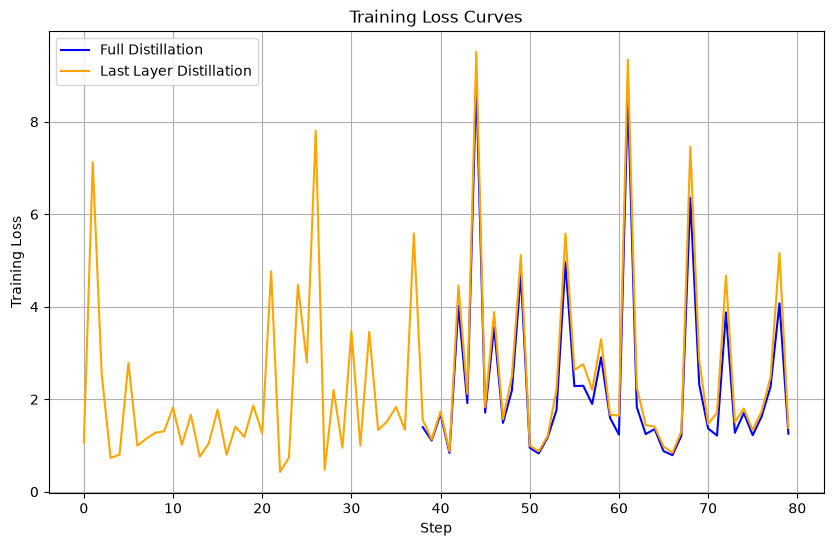

In [ ]:
# Plotting and saving loss curves

#paths
# data/full_distilled/logs/full/version_8/metrics.csv
# data/last_layer_distilled/logs/last_layer/version_3/metrics.csv
# one plot with both
plt.figure(figsize=(10, 6))
# Load full distillation metrics
full_metrics_path = Path("data/full_distilled/logs/full/version_8/metrics.csv")
last_layer_metrics_path = Path("data/last_layer_distilled/logs/last_layer/version_3/metrics.csv")

#plot both togheter
plt.figure(figsize=(10, 6))
if full_metrics_path.exists():
    with full_metrics_path.open(newline="", encoding="utf-8") as source:
        reader = csv.DictReader(source)
        steps = []
        losses = []
        for row in reader:
            if row.get("train_loss_step"):
                steps.append(int(row["step"]))
                losses.append(float(row["train_loss_step"]))
        plt.plot(steps, losses, label="Full Distillation", color="blue")
if last_layer_metrics_path.exists():
    with last_layer_metrics_path.open(newline="", encoding="utf-8") as source:
        reader = csv.DictReader(source)
        steps = []
        losses = []
        for row in reader:
            if row.get("train_loss_step"):
                steps.append(int(row["step"]))
                losses.append(float(row["train_loss_step"]))
        plt.plot(steps, losses, label="Last Layer Distillation", color="orange")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()
plt.savefig("training_loss_curves.png")
plt.show()


Evaluating Baseline...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take prec

Evaluating Full distillation...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

Some parameters are on the meta device because they were offloaded to the disk and cpu.
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take prec


Validation summary (answer mentioned = correct):


,difficulty,model,accuracy_percent,correct,examples,mean_response_words
0,easy,Baseline,50.000000,7,14,77.857143
1,easy,Full distillation,57.142857,8,14,63.642857
2,easy,Last-layer distillation,50.000000,7,14,77.857143
3,medium,Baseline,0.000000,0,13,71.384615
4,medium,Full distillation,0.000000,0,13,70.615385
5,medium,Last-layer distillation,0.000000,0,13,71.384615
6,hard,Baseline,7.692308,1,13,66.692308
7,hard,Full distillation,0.000000,0,13,69.692308
8,hard,Last-layer distillation,7.692308,1,13,66.692308



Accuracy by function type:


,function_type,model,accuracy_percent,examples
0,composite,Baseline,20.000000,5
1,composite,Full distillation,0.000000,5
2,composite,Last-layer distillation,20.000000,5
3,exponential,Baseline,14.285714,7
4,exponential,Full distillation,28.571429,7
5,exponential,Last-layer distillation,14.285714,7
6,logarithmic,Baseline,0.000000,6
7,logarithmic,Full distillation,0.000000,6
8,logarithmic,Last-layer distillation,0.000000,6
9,polynomial_deg_1,Baseline,100.000000,5


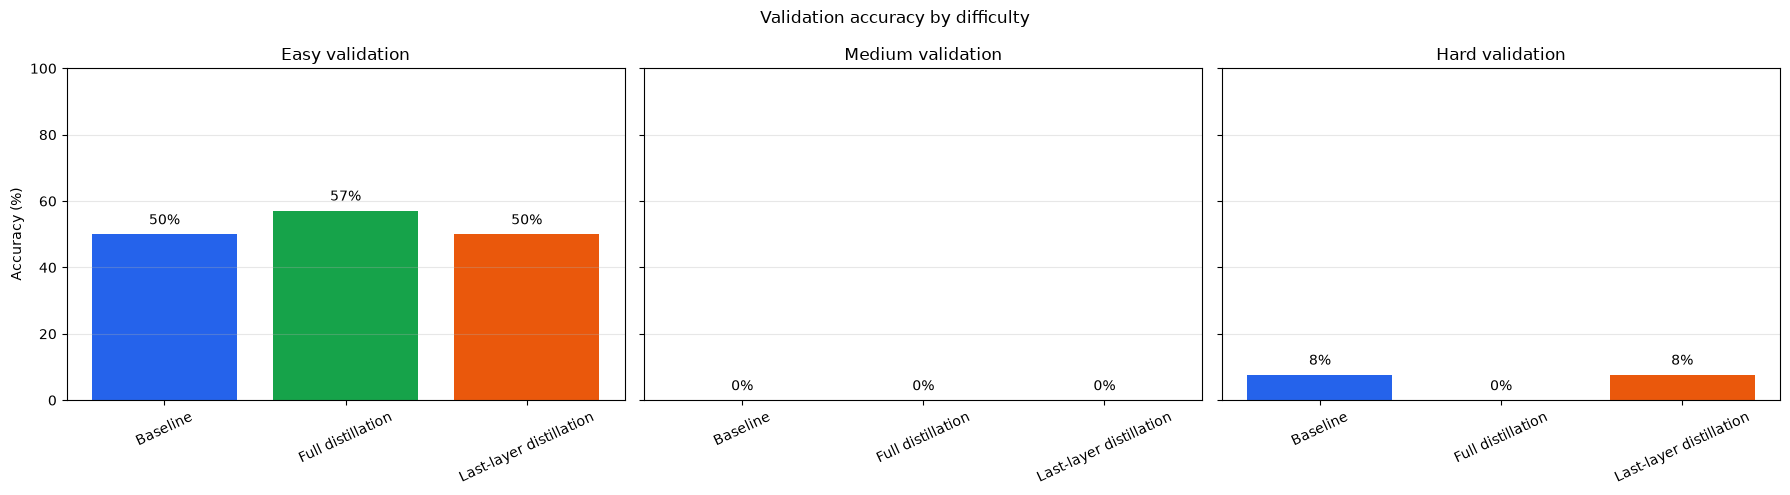


Overall comparison:


,accuracy_percent,mean_response_words
model,,
Baseline,20.0,72.125
Full distillation,20.0,67.875
Last-layer distillation,20.0,72.125


In [ ]:
# Validation by difficulty: compare the baseline, full-distilled, and last-layer models.
VAL_DATA_PATH = Path("./data/val_data.jsonl")
VALIDATION_MODEL_PATHS = {
    "Baseline": "./models/llama-3.2-3b",
    "Full distillation": "./data/full_distilled/final",
    "Last-layer distillation": "./data/last_layer_distilled/final",
}

def _load_validation_records(path):
    with path.open(encoding="utf-8") as source:
        records = [json.loads(line) for line in source if line.strip()]
    if not records:
        raise ValueError(f"No validation records found in {path}")
    required = {"answer", "difficulty", "function_type", "input_prompt"}
    missing = required.difference(records[0])
    if missing:
        raise ValueError(f"Validation data is missing fields: {sorted(missing)}")
    return records


def _normalize_math_text(value):
    """Normalize common formatting differences without changing the target meaning."""
    text = str(value).strip().lower()
    text = text.replace("\\\\", "\\")
    text = re.sub(r"\\(?:boxed|left|right|displaystyle)", "", text)
    text = text.replace("\\cdot", "*").replace("\\times", "*")
    text = text.replace("^", "**")
    text = re.sub(r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}", r"(\1)/(\2)", text)
    text = re.sub(r"\\([a-z]+)", r"\1", text)
    return re.sub(r"\s+", "", text)


def _answer_is_mentioned(reference, generated):
    target = _normalize_math_text(reference)
    prediction = _normalize_math_text(generated)
    if not target:
        return False
    # Avoid counting a numeric answer embedded inside a larger number.
    boundary_left = r"(?<![a-z0-9])" if target[0].isalnum() else ""
    boundary_right = r"(?![a-z0-9])" if target[-1].isalnum() else ""
    return re.search(boundary_left + re.escape(target) + boundary_right, prediction) is not None


def _generate_validation_outputs(records, model_name, model_path):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"{model_name} model is not available: {model_path}")
    generator = pipeline(
        "text-generation",
        model=str(model_path),
        tokenizer=str(model_path),
        dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        max_new_tokens = 256,
    )
    outputs = []
    for record in records:
        result = generator(
            f"predict: {record['input_prompt']}",
            max_new_tokens=128,
            do_sample=False,
            return_full_text=False,
        )
        generated = result[0]["generated_text"].strip()
        outputs.append({
            **record,
            "model": model_name,
            "generated_answer": generated,
            "correct": _answer_is_mentioned(record["answer"], generated),
            "response_words": len(generated.split()),
        })
    del generator
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return outputs


validation_records = _load_validation_records(VAL_DATA_PATH)
validation_outputs = []
for model_name, model_path in VALIDATION_MODEL_PATHS.items():
    print(f"Evaluating {model_name}...")
    validation_outputs.extend(_generate_validation_outputs(validation_records, model_name, model_path))

validation_df = pd.DataFrame(validation_outputs)
validation_df["difficulty"] = pd.Categorical(
    validation_df["difficulty"], categories=["easy", "medium", "hard"], ordered=True
)
validation_df["accuracy"] = validation_df["correct"].astype(float)

summary = (
    validation_df.groupby(["difficulty", "model"], observed=False)
    .agg(
        accuracy=("accuracy", "mean"),
        correct=("correct", "sum"),
        examples=("correct", "size"),
        mean_response_words=("response_words", "mean"),
    )
    .reset_index()
)
summary["accuracy_percent"] = summary["accuracy"] * 100
print("\nValidation summary (answer mentioned = correct):")
display(summary[["difficulty", "model", "accuracy_percent", "correct", "examples", "mean_response_words"]])

function_summary = (
    validation_df.groupby(["function_type", "model"], observed=False)
    .agg(accuracy=("accuracy", "mean"), examples=("correct", "size"))
    .reset_index()
)
function_summary["accuracy_percent"] = function_summary["accuracy"] * 100
print("\nAccuracy by function type:")
display(function_summary[["function_type", "model", "accuracy_percent", "examples"]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for axis, difficulty in zip(axes, ["easy", "medium", "hard"]):
    difficulty_summary = summary[summary["difficulty"] == difficulty]
    bars = axis.bar(
        difficulty_summary["model"],
        difficulty_summary["accuracy_percent"],
        color=["#2563eb", "#16a34a", "#ea580c"],
    )
    axis.set_title(f"{difficulty.capitalize()} validation")
    axis.set_ylabel("Accuracy (%)" if difficulty == "easy" else "")
    axis.set_ylim(0, 100)
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.3)
    for bar, value in zip(bars, difficulty_summary["accuracy_percent"]):
        axis.text(bar.get_x() + bar.get_width() / 2, value + 3, f"{value:.0f}%", ha="center")
fig.suptitle("Validation accuracy by difficulty")
fig.tight_layout()
plt.show()

overall = (
    validation_df.groupby("model")
    .agg(accuracy=("accuracy", "mean"), mean_response_words=("response_words", "mean"))
    .sort_values("accuracy", ascending=False)
)
overall["accuracy_percent"] = overall["accuracy"] * 100
print("\nOverall comparison:")
display(overall[["accuracy_percent", "mean_response_words"]])


In [ ]:
#CELL FOR EXAMPLES
# Validation by difficulty: compare the baseline, full-distilled, and last-layer models.

VAL_DATA_PATH = Path("./data/val_data.jsonl")
VALIDATION_MODEL_PATHS = {
    "Baseline": "./models/llama-3.2-3b",
    "Full distillation": "./data/full_distilled/final",
    "Last-layer distillation": "./data/last_layer_distilled/final",
}


def _load_validation_records(path):
    with path.open(encoding="utf-8") as source:
        records = [json.loads(line) for line in source if line.strip()]
    if not records:
        raise ValueError(f"No validation records found in {path}")
    required = {"answer", "difficulty", "function_type", "input_prompt"}
    missing = required.difference(records[0])
    if missing:
        raise ValueError(f"Validation data is missing fields: {sorted(missing)}")
    return records

validation_records = _load_validation_records(VAL_DATA_PATH)
examples = []
e = 0
m = 0 
h = 0
for items in validation_records:
    if items["difficulty"] == "easy" and e < 1:
        examples.append(items)
        e += 1
    elif items["difficulty"] == "medium" and m < 1:
        examples.append(items)
        m += 1
    elif items["difficulty"] == "hard" and h < 1:
        examples.append(items)
        h += 1
    if e  and m  and h:
        break
print("Selected examples for demonstration:")
print(examples)


Selected examples for demonstration:
[{'id': 1, 'input_prompt': 'Compute the derivative: -3*x - 2 (Show work)', 'answer_rationale': 'The derivative of -3x is -3, and the derivative of constant -2 is 0. Thus, the derivative is -3.', 'answer': '-3', 'difficulty': 'easy', 'function_type': 'polynomial_deg_1', 'split': 'val'}, {'id': 6, 'input_prompt': 'What is the derivative of f(x) = x + 5*sin(x)? (Step by step)', 'answer_rationale': 'Derivative of x is 1, derivative of sin(x) is cos(x), so derivative of 5 sin(x) is 5 cos(x). Summing gives 1+5 cos(x).', 'answer': '1+5 cos(x)', 'difficulty': 'hard', 'function_type': 'trig', 'split': 'val'}, {'id': 11, 'input_prompt': 'Find the derivative of: f(x) = 10*x**3 - 2*x**2 - 4*x + 1 Express in simplified form.', 'answer_rationale': 'Apply the power rule: derivative of 10x^3 is 30x^2, derivative of -2x^2 is -4x, derivative of -4x is -4, derivative of 1 is 0. Combine to get 30x^2 - 4x - 4.', 'answer': '30x^2 - 4x - 4', 'difficulty': 'medium', 'funct

In [ ]:
def _normalize_math_text(value):
    """Normalize common formatting differences without changing the target meaning."""
    text = str(value).strip().lower()
    text = text.replace("\\\\", "\\")
    text = re.sub(r"\\(?:boxed|left|right|displaystyle)", "", text)
    text = text.replace("\\cdot", "*").replace("\\times", "*")
    text = text.replace("^", "**")
    text = re.sub(r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}", r"(\1)/(\2)", text)
    text = re.sub(r"\\([a-z]+)", r"\1", text)
    return re.sub(r"\s+", "", text)


def _answer_is_mentioned(reference, generated):
    target = _normalize_math_text(reference)
    prediction = _normalize_math_text(generated)
    if not target:
        return False
    # Avoid counting a numeric answer embedded inside a larger number.
    boundary_left = r"(?<![a-z0-9])" if target[0].isalnum() else ""
    boundary_right = r"(?![a-z0-9])" if target[-1].isalnum() else ""
    return re.search(boundary_left + re.escape(target) + boundary_right, prediction) is not None


def _generate_validation_outputs(records, model_name, model_path):
    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f"{model_name} model is not available: {model_path}")
    generator = pipeline(
        "text-generation",
        model=str(model_path),
        tokenizer=str(model_path),
        dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
    )
    outputs = []
    for record in records:
        result = generator(
            f"predict: {record['input_prompt']}",
            max_new_tokens=128,
            do_sample=False,
            return_full_text=False,
        )
        generated = result[0]["generated_text"].strip()
        outputs.append({
            **record,
            "model": model_name,
            "generated_answer": generated,
            "correct": _answer_is_mentioned(record["answer"], generated),
            "response_words": len(generated.split()),
        })
    del generator
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return outputs


validation_df = pd.DataFrame(examples)


    id                                       input_prompt  \
0    1       Compute the derivative: -3*x - 2 (Show work)   
1    6  What is the derivative of f(x) = x + 5*sin(x)?...   
2   11  Find the derivative of: f(x) = 10*x**3 - 2*x**...   
3    1       Compute the derivative: -3*x - 2 (Show work)   
4    6  What is the derivative of f(x) = x + 5*sin(x)?...   
5   11  Find the derivative of: f(x) = 10*x**3 - 2*x**...   
6    1       Compute the derivative: -3*x - 2 (Show work)   
7    6  What is the derivative of f(x) = x + 5*sin(x)?...   
8   11  Find the derivative of: f(x) = 10*x**3 - 2*x**...   
9    1       Compute the derivative: -3*x - 2 (Show work)   
10   6  What is the derivative of f(x) = x + 5*sin(x)?...   
11  11  Find the derivative of: f(x) = 10*x**3 - 2*x**...   
12   1       Compute the derivative: -3*x - 2 (Show work)   
13   6  What is the derivative of f(x) = x + 5*sin(x)?...   
14  11  Find the derivative of: f(x) = 10*x**3 - 2*x**...   
15   1       Compute the

In [15]:
validation_df = pd.DataFrame(validation_df)

example_df = validation_df
for index, row in example_df.iterrows():
    print(f"Example ID: {row['id']}")
    print(f"Difficulty: {row['difficulty'].upper()}")
    print(f"Type: {row['function_type'].upper()}")
    print(f"Function: {row['function_type']}")
    print(f"Input Prompt: {row['input_prompt']}")
    print(f"Reference Answer: {row['answer']}")
    print(f"Model: {row['model']}")
    print(f"Generated Answer: {row['generated_answer']}")
    print(f"Correct: {'Yes' if row['correct'] else 'No'}")
    print(f"Response Words: {row['response_words']}")
    print("-" * 70)

Example ID: 1
Difficulty: EASY
Type: POLYNOMIAL_DEG_1
Function: polynomial_deg_1
Input Prompt: Compute the derivative: -3*x - 2 (Show work)
Reference Answer: -3
Model: nan
Generated Answer: nan
Correct: Yes
Response Words: nan
----------------------------------------------------------------------
Example ID: 6
Difficulty: HARD
Type: TRIG
Function: trig
Input Prompt: What is the derivative of f(x) = x + 5*sin(x)? (Step by step)
Reference Answer: 1+5 cos(x)
Model: nan
Generated Answer: nan
Correct: Yes
Response Words: nan
----------------------------------------------------------------------
Example ID: 11
Difficulty: MEDIUM
Type: POLYNOMIAL_DEG_3
Function: polynomial_deg_3
Input Prompt: Find the derivative of: f(x) = 10*x**3 - 2*x**2 - 4*x + 1 Express in simplified form.
Reference Answer: 30x^2 - 4x - 4
Model: nan
Generated Answer: nan
Correct: Yes
Response Words: nan
----------------------------------------------------------------------
Example ID: 1
Difficulty: EASY
Type: POLYNOMIAL_D